In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cleaned_stray_animal_reports.csv")

df.head()

,Report_ID,Animal_Type,Breed,Age,Gender,Health_Status,Location,Reported_Date,Rescue_Status
0,1,Dog,Beagle,5,Male,Healthy,Negombo,2026-01-13,Rescued
1,2,Dog,Labrador,15,Female,Healthy,Galle,2026-01-28,Rescued
2,3,Cat,Domestic Short Hair,5,Male,Healthy,Colombo,2026-05-22,Rescued
3,4,Dog,Golden Retriever,1,Male,Critical,Jaffna,2026-04-29,Released
4,5,Dog,Beagle,5,Male,Sick,Colombo,2026-01-27,Under Treatment


In [3]:
df["Reported_Date"] = pd.to_datetime(df["Reported_Date"])

In [4]:
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

Number of records: 1000
Number of columns: 9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Report_ID      1000 non-null   int64         
 1   Animal_Type    1000 non-null   object        
 2   Breed          1000 non-null   object        
 3   Age            1000 non-null   int64         
 4   Gender         1000 non-null   object        
 5   Health_Status  1000 non-null   object        
 6   Location       1000 non-null   object        
 7   Reported_Date  1000 non-null   datetime64[ns]
 8   Rescue_Status  1000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


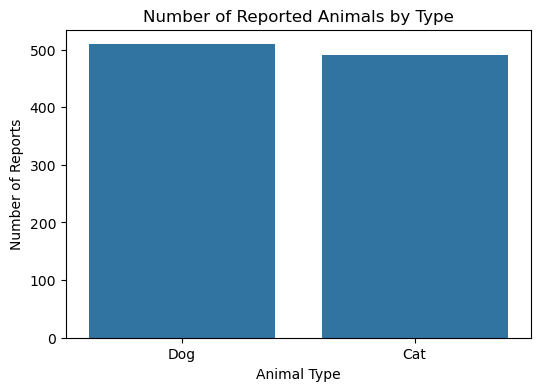

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Animal_Type")

plt.title("Number of Reported Animals by Type")
plt.xlabel("Animal Type")
plt.ylabel("Number of Reports")

plt.show()

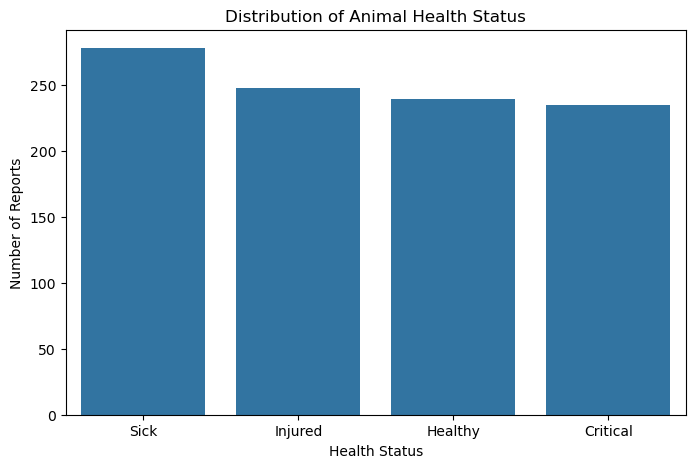

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Health_Status",
    order=df["Health_Status"].value_counts().index
)

plt.title("Distribution of Animal Health Status")
plt.xlabel("Health Status")
plt.ylabel("Number of Reports")

plt.show()

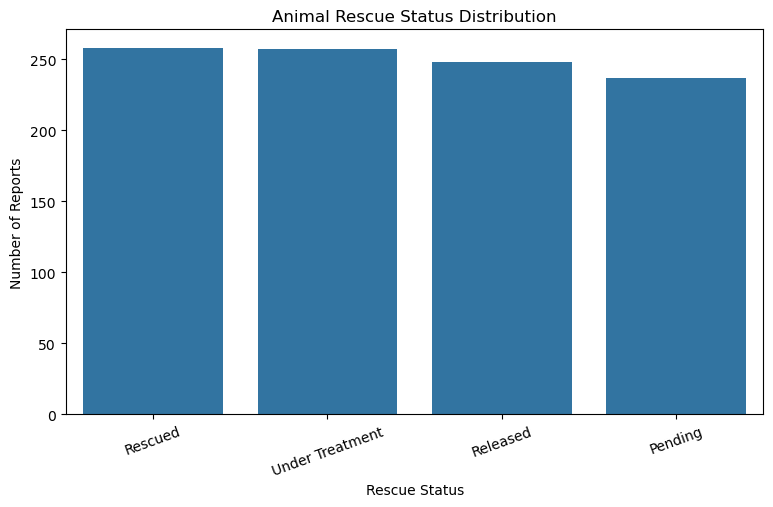

In [8]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Rescue_Status",
    order=df["Rescue_Status"].value_counts().index
)

plt.title("Animal Rescue Status Distribution")
plt.xlabel("Rescue Status")
plt.ylabel("Number of Reports")

plt.xticks(rotation=20)

plt.show()

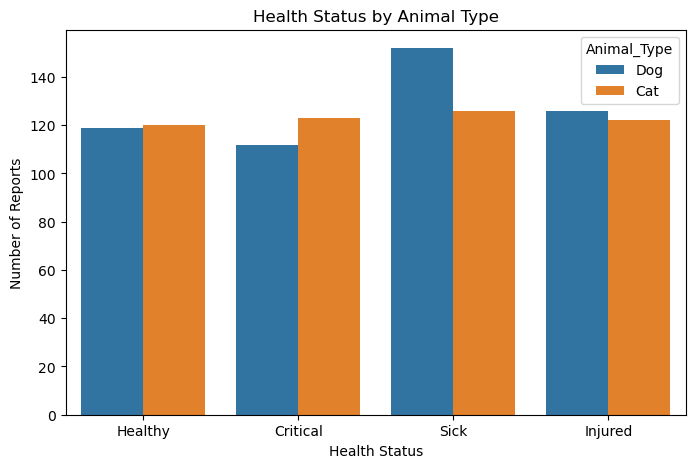

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Health_Status",
    hue="Animal_Type"
)

plt.title("Health Status by Animal Type")
plt.xlabel("Health Status")
plt.ylabel("Number of Reports")

plt.show()

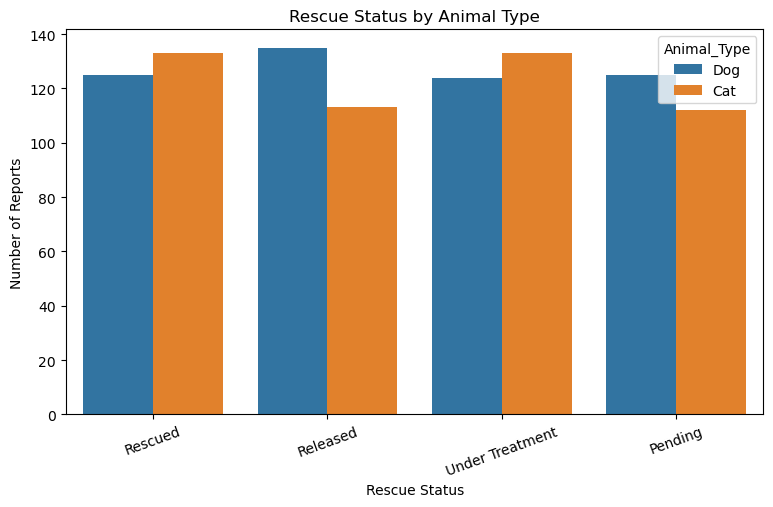

In [10]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Rescue_Status",
    hue="Animal_Type"
)

plt.title("Rescue Status by Animal Type")
plt.xlabel("Rescue Status")
plt.ylabel("Number of Reports")

plt.xticks(rotation=20)

plt.show()

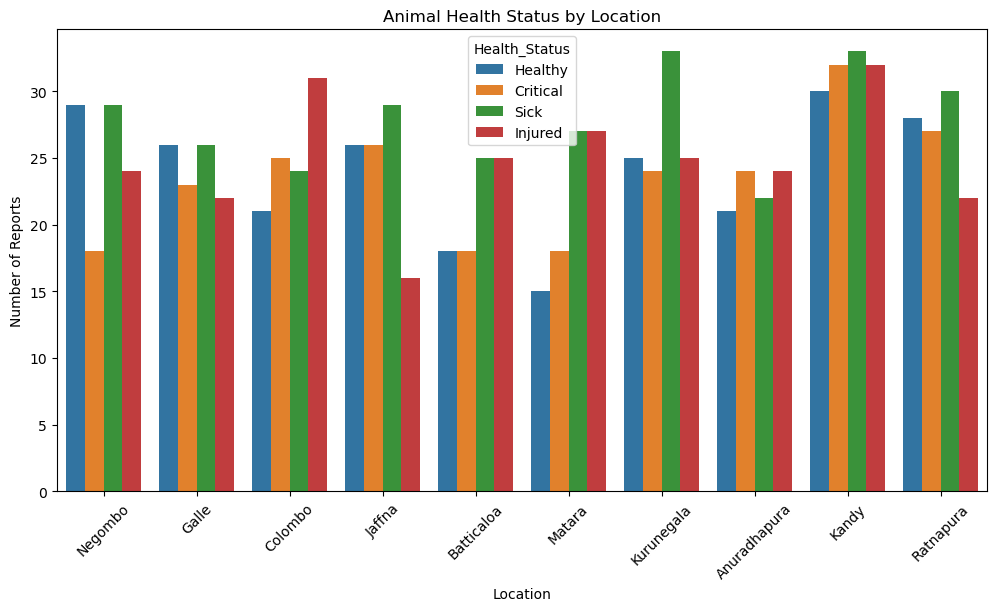

In [11]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Location",
    hue="Health_Status"
)

plt.title("Animal Health Status by Location")
plt.xlabel("Location")
plt.ylabel("Number of Reports")

plt.xticks(rotation=45)

plt.show()

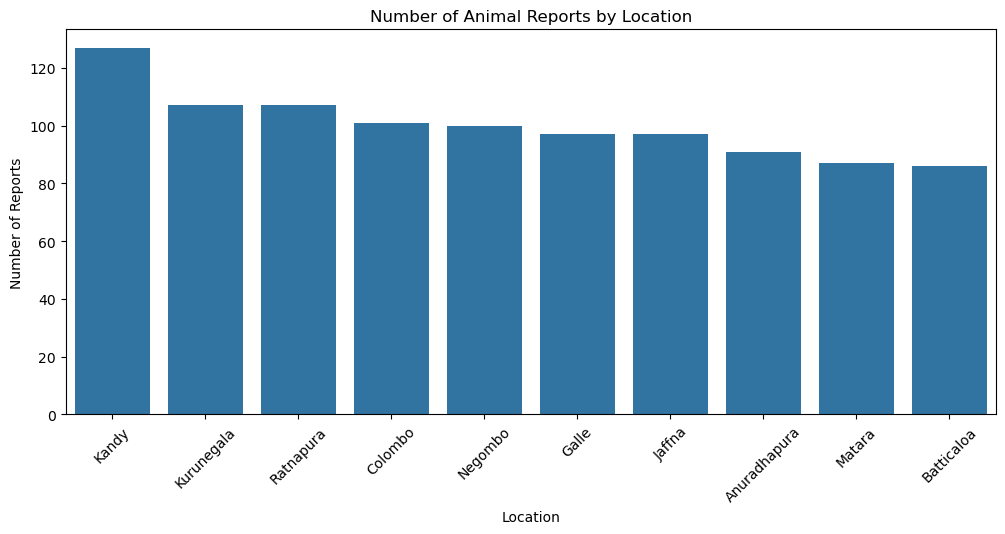

In [12]:
plt.figure(figsize=(12, 5))

location_counts = df["Location"].value_counts()

sns.barplot(
    x=location_counts.index,
    y=location_counts.values
)

plt.title("Number of Animal Reports by Location")
plt.xlabel("Location")
plt.ylabel("Number of Reports")

plt.xticks(rotation=45)

plt.show()

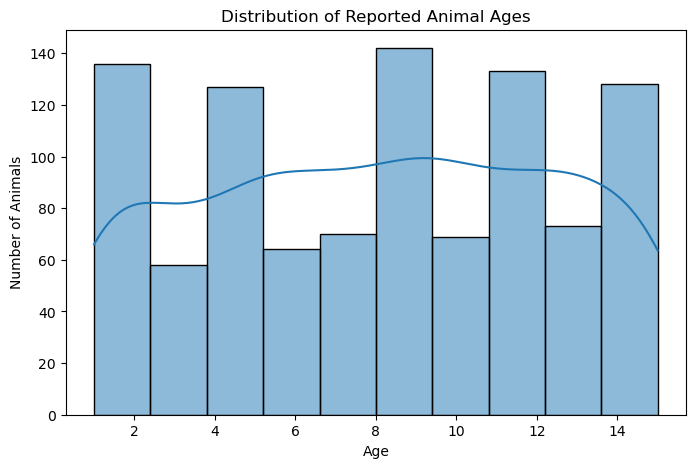

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=10,
    kde=True
)

plt.title("Distribution of Reported Animal Ages")
plt.xlabel("Age")
plt.ylabel("Number of Animals")

plt.show()

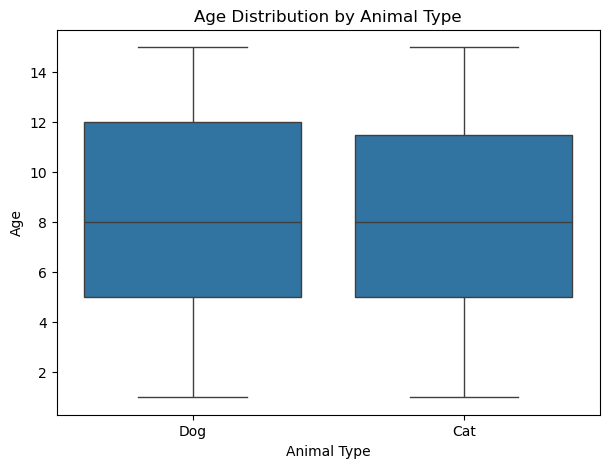

In [14]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Animal_Type",
    y="Age"
)

plt.title("Age Distribution by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Age")

plt.show()

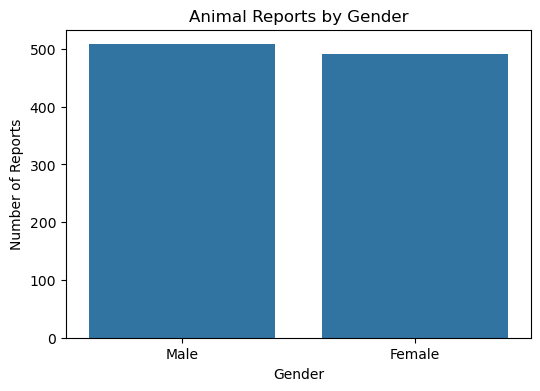

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Animal Reports by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Reports")

plt.show()

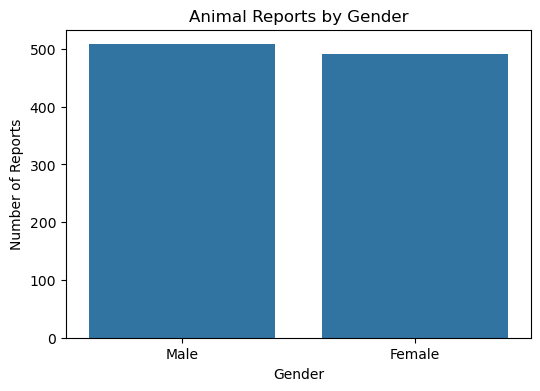

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Animal Reports by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Reports")

plt.show()

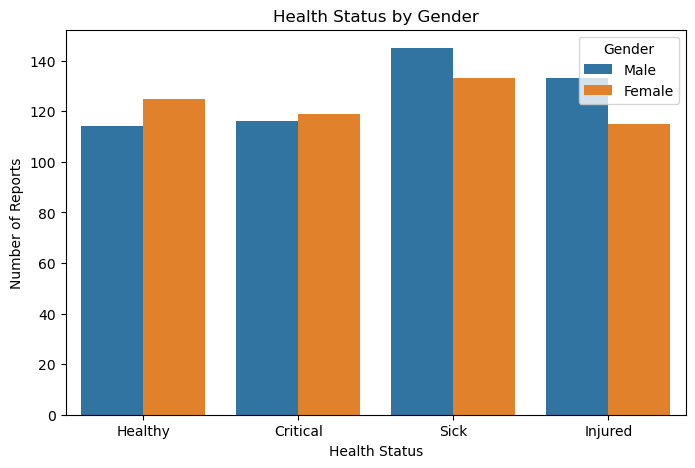

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Health_Status",
    hue="Gender"
)

plt.title("Health Status by Gender")
plt.xlabel("Health Status")
plt.ylabel("Number of Reports")

plt.show()

In [18]:
df["Month"] = df["Reported_Date"].dt.to_period("M").astype(str)

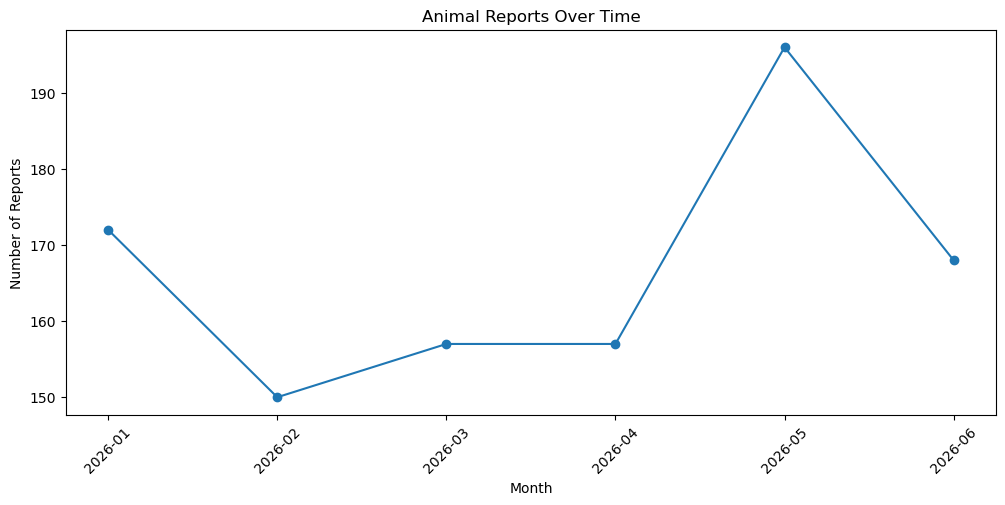

In [19]:
monthly_reports = df.groupby("Month").size()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_reports.index,
    monthly_reports.values,
    marker="o"
)

plt.title("Animal Reports Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reports")

plt.xticks(rotation=45)

plt.show()

In [20]:
health_rescue = pd.crosstab(
    df["Health_Status"],
    df["Rescue_Status"]
)

health_rescue

Rescue_Status,Pending,Released,Rescued,Under Treatment
Health_Status,,,,
Critical,58,46,69,62
Healthy,66,51,62,60
Injured,50,66,67,65
Sick,63,85,60,70


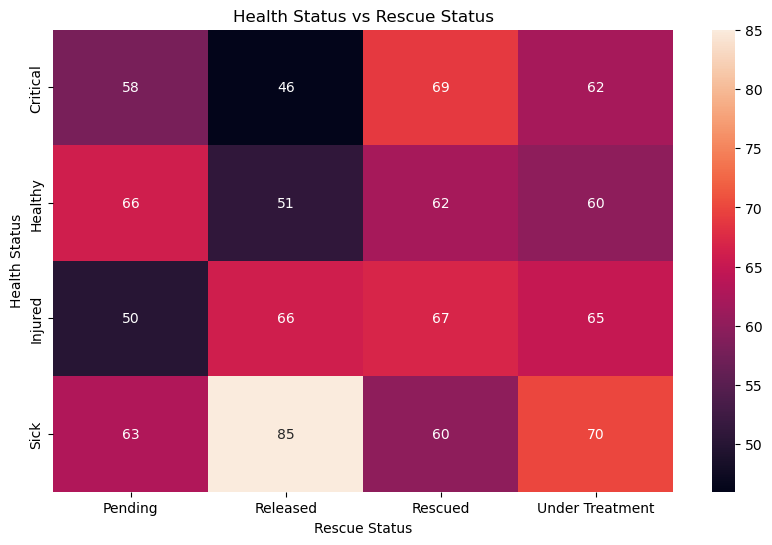

In [21]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    health_rescue,
    annot=True,
    fmt="d"
)

plt.title("Health Status vs Rescue Status")
plt.xlabel("Rescue Status")
plt.ylabel("Health Status")

plt.show()

In [22]:
health_location = pd.crosstab(
    df["Location"],
    df["Health_Status"],
    normalize="index"
) * 100

health_location.round(2)

Health_Status,Critical,Healthy,Injured,Sick
Location,,,,
Anuradhapura,26.37,23.08,26.37,24.18
Batticaloa,20.93,20.93,29.07,29.07
Colombo,24.75,20.79,30.69,23.76
Galle,23.71,26.80,22.68,26.80
Jaffna,26.80,26.80,16.49,29.90
Kandy,25.20,23.62,25.20,25.98
Kurunegala,22.43,23.36,23.36,30.84
Matara,20.69,17.24,31.03,31.03
Negombo,18.00,29.00,24.00,29.00


<Figure size 1200x600 with 0 Axes>

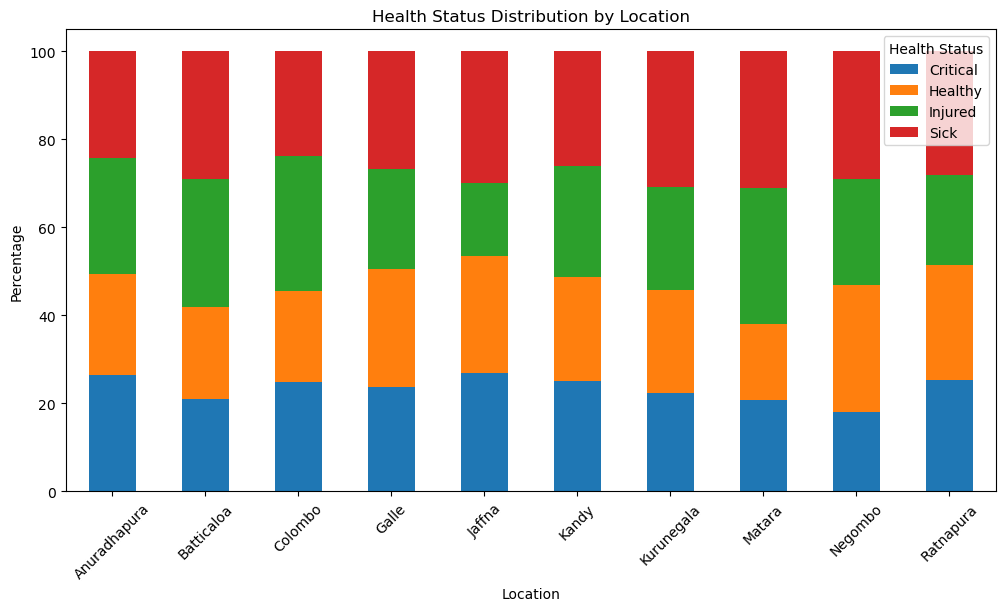

In [23]:
plt.figure(figsize=(12, 6))

health_location.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Health Status Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Percentage")

plt.legend(title="Health Status")

plt.xticks(rotation=45)

plt.show()

In [24]:
df["Animal_Type"].value_counts()

Animal_Type
Dog    509
Cat    491
Name: count, dtype: int64

In [25]:
df["Health_Status"].value_counts()

Health_Status
Sick        278
Injured     248
Healthy     239
Critical    235
Name: count, dtype: int64

In [26]:
df["Rescue_Status"].value_counts()

Rescue_Status
Rescued            258
Under Treatment    257
Released           248
Pending            237
Name: count, dtype: int64

In [27]:
df["Location"].value_counts()

Location
Kandy           127
Kurunegala      107
Ratnapura       107
Colombo         101
Negombo         100
Galle            97
Jaffna           97
Anuradhapura     91
Matara           87
Batticaloa       86
Name: count, dtype: int64

In [28]:
pd.crosstab(
    df["Health_Status"],
    df["Rescue_Status"]
)

Rescue_Status,Pending,Released,Rescued,Under Treatment
Health_Status,,,,
Critical,58,46,69,62
Healthy,66,51,62,60
Injured,50,66,67,65
Sick,63,85,60,70


In [29]:
pd.crosstab(
    df["Animal_Type"],
    df["Health_Status"]
)

Health_Status,Critical,Healthy,Injured,Sick
Animal_Type,,,,
Cat,123,120,122,126
Dog,112,119,126,152


In [30]:
y = df["Health_Status"]